# Modeling

This notebook uses the features data from the folder data/processed and creates additional features.  

%TODO: TUNE THE CAUSALFORESTDML!!!!

In [130]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from c08_farming_exit import config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor
from econml.dml import CausalForestDML
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter
from econml.validate import DRTester


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
# #In case you want to run Stata in a cell using the magic command %%stata, initialize it first!
# from c08_farming_exit.stata_utils import init_stata
# init_stata()

## 1. Import features data

In [89]:
df = pd.read_csv(config.PROCESSED_DATA_DIR / "features_data.csv")

## 2. Preparation and inputs

In [90]:
geo_cols = ['district', 'enumeration_area', 'region'] #these columns are missing for Botwana and Namibia
identification_cols = ['personal_id',  'interview_key', 'members_id']
df = df.drop(columns = geo_cols + identification_cols)

Y = 'off_farm_hours_annual_share'
df = df.dropna(subset=Y) # can't train on unlabeled rows

T_input = [ 'land_size_cropland_acres',
            'land_size_fallow_acres',
            'land_size_agroforestry_forestry_acres',
            'land_size_pasture_acres']

T = 'agriculture_land_acres'

T_2 =   'land_number_of_plots'
#what about the average plot size? 

X = [   'female',
        #'relation_to_head',
        'age',
        #'years_of_schooling',
        ]

W = [
        #geographics
        'country', 

        #socio-demographics
        'ethnic_group',
        'religion',
        'answered_for_self', 
    
        #land ownership
        'land_size_residential_acres',
        'land_size_lodge_camp_acres',
        'land_cropland_ownership_status',
        'land_residential_ownership_status',
        'grazing_land_ownership_status',
        'grazing_land_number_hh_sharing',
        'grazing_land_permit',
        'grazing_land_permit_price',
        'grazing_land_use_duration_in_years',

        #contracts/membership
        'livestock_contract',
        'crop_contract',
        'crop_contract_crop_type',
        'membership_farmers_group',
        'membership_agricultural_cooperative',

        #market distance and road quality
        'livestock_market_distance_in_km',
        'road_type',
        'road_condition',
        'road_distance_in_minutes',
        'market_output_distance_in_km',
        'market_input_distance_in_km',
        'market_type',

        #subsidies
        'subsidy',
        'subsidy_type_seeds',
        'subsidy_type_fertilizer',
        'subsidy_type_agro_chemicals',
        'subsidy_type_interest_free_loan',
        'subsidy_supplier_government',
        'subsidy_supplier_ngos',
        'subsidy_supplier_company',

        #assets
        'asset_value',
        'asset_diversity',
        'house_room_number',
        'house_roof_material',
        'house_wall_material',
        'house_floor_material',
        'house_water_source',
        'house_toilet_type',
        'house_energy_source',
        'house_energy_source_for_cooking',
        'house_energy_source_for_lighting',

        #mobile money and internet
        'internet_access',
        'internet_access_at_home',
        'mobile_money_access',
        
        #emotions
        'worry_about_job_loss_or_economic_livelihood',
        'life_satisfaction',
        'hh_optimism_index',
        'hh_sentiment_index',

        #add ons
        'sufficent_food_number_of_month',
        'hh_members_count',
        'beans_allocated_to_empl_occupation',
        'grazing_land_challenges_index',

        #other income/remittances
        'other_income_amount_annual',
        'remittance_amount_sent_last_12_months',

        #shock/coping
        'shock_type_affected_last_12_months_crop_failure',
        'shock_type_affected_last_12_months_drought',
        'shock_type_affected_last_12_months_floods',
        'shock_type_affected_last_12_months_illness_death',
        'shock_type_affected_last_12_months_livestock_loss',
        'shock_type_affected_last_12_months_other',
        'shock_type_affected_last_12_months_price_shock',
        'shock_coping_strategy_relatives_friends',
        'shock_coping_strategy_government',
        'shock_coping_strategy_food_reduction',
        'shock_coping_strategy_changed_cropping_practices',
        'shock_coping_strategy_more_employment',
        'shock_coping_strategy_hh_member_migration',
        'shock_coping_strategy_savings',
        'shock_coping_strategy_insurance',
        'shock_coping_strategy_credit',
        'shock_coping_strategy_sold_hh_assets',
        'shock_coping_strategy_sold_livestock',
        'shock_coping_strategy_migration',
        'shock_future_likelihood_change_income_source',

        #migration
        'migrant_last_12_months',
        'current_migrant',
        'migration_intention_next_12_months',
        
        #financing 
        'land_used_as_collateral',
        'agriculture_loan_last_5_years',
        'agriculture_loan_amount',
        'agriculture_loan_lender_bank',
        'agriculture_loan_lender_credit_union',
        'agriculture_loan_lender_private_lender',
        'agriculture_loan_lender_government',
        'agriculture_loan_lender_ngos',
 ]

df = df[[Y] + T_input + [T_2] + X + W]

## 3. Missings and outlier treatment

In [91]:
# profile_report_name = "pandas_profile_report_causal_forest"
# profile = ProfileReport(df, title="Farming Exit - Causal Forest Input")
# profile.to_file(f"../output/{profile_report_name}.html")

In [92]:
# 1. Select numeric columns (float64 and int64) and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
obj_cols = df.select_dtypes(include=['object']).columns

# 2. Outlier treatment: clip values outside the 1%/99% quantiles, ignoring NaNs
for col in num_cols:
    lower = df[col].quantile(0.01)   # quantile() ignores NaNs by default
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

# 3. Fill numeric NaNs with sentinel value
df[num_cols] = df[num_cols].fillna(99999)

# 4. Fill object NaNs/Nones with "missing"
df[obj_cols] = df[obj_cols].fillna("missing")

## 4. Create final treatment

In [93]:
#THE TARGET INPUTS SHOULD NOT CONTAIN 9999 IN CASE OF MISSINGS; BUT RATHER THE COUNTRY MEDIAN

#TARGET 1
T_input = ['land_size_cropland_acres',
           'land_size_fallow_acres',
           'land_size_agroforestry_forestry_acres',
           'land_size_pasture_acres']

for col in T_input:
    s = df[col].replace(99999, np.nan)
    medians = s.groupby(df['country']).transform('median')
    df[col] = s.fillna(medians)

df['agriculture_land_acres'] = df[T_input].sum(axis=1)
df = df.drop(columns=T_input)

#TARGET 2
s = df['land_number_of_plots'].replace(99999, np.nan)
median = s.groupby(df['country']).transform('median')
df['land_number_of_plots'] = s.fillna(median)

## 5. Causal Forest

Understanding the linearity assumption

Continous treatment \
Local in X (each leaf has its own CATE): e.g. for young females, +1 unit increase in land size has a -1 effect on off-farm work.  For young males, +1 unit increase in land size has a +3 effect on off-farm work. \
Linear in T (constant marginal effects across T): The impact of moving T from 1 to 2 is assumed to be identical to moving T from 100 to 101 for the same individual.


In [94]:
#ONE-HOT-ENCODING FOR CATEGORICAL VARIABLES 
df = pd.get_dummies(df, dummy_na=False)

# we need to correct the list of columns in W as there are one-hot-encoded variables now 
W = [c for c in df.columns if c not in [Y, T] + X]

### 5.1 First Stage: DoubleML

In [ ]:
# FIRST STAGE MODELS (Optimized for 4500 rows, 90 features)
# xgboost can handle many missings/99999!

xgb_param_grid = {
    # Keep trees shallow to avoid overfitting to 4,500 rows
    'max_depth': [2, 3, 4],
    
    # Subsample both rows and features (creates strong regularizing noise)
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],  # Subsample columns too!
    
    # Pair learning rate with n_estimators (low rate + moderate trees)
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [100, 150, 200],
    
    # L2 Regularization (higher values heavily penalize complex leaf weights)
    'reg_lambda': [5.0, 10.0]
}

tuned_xgb_y = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=1),
    param_distributions=xgb_param_grid,
    n_iter=1000, # RandomizedSearchCV picks 100 random settings out of your full parameter grid
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

tuned_xgb_t = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=1),
    param_distributions=xgb_param_grid,
    n_iter=1000, # RandomizedSearchCV picks 100 random settings out of your full parameter grid
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

In [ ]:
#Define the model
# ECONML DOES NOT PERFORM ON MISSINGS (AS IS USES SKLEARN IN THE BACKGROUND) 
# SECOND STAGE ONLY USES X FOR SPLITTING. MAKE SURE THAT ALL FEATURES IN X HAVE NOT MANY MISSINGS AND ARE CLEAN!
#TODO: TUNE HERE!
est = CausalForestDML(
    model_y=tuned_xgb_y,
    model_t=tuned_xgb_t,
    discrete_outcome=False,   #use a regression, not a classification
    discrete_treatment=False, #use a regression, not a classification
    n_estimators=1000,        # High number of trees ensures stable causal predictions
    min_samples_leaf=50,      # Minimum rows per leaf protects continuous slope estimation
    cv=3,                     # 3-fold cross-fitting splits your 4500 rows into safe validation chunks
    verbose=0,
    max_depth=50,
    random_state=42
)

#Tune and fit the model
est.tune(df[Y], df[T], X=df[X], W=df[W])
est.fit(Y=df[Y], T=df[T], X=df[X], W=df[W], cache_values=True)

c:\Users\localuser\my_projects\c08-farming-exit\.venv\Lib\site-packages\econml\sklearn_extensions\model_selection.py:554: UserWarning: Model RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
        

KeyboardInterrupt: 

In [133]:
#create an array out of the features and treatment
XW = np.hstack([df[X].to_numpy(dtype=float),
                df[W].to_numpy(dtype=float)])
t  = df[T].to_numpy(dtype=float)
y  = df[Y].to_numpy(dtype=float)

In [146]:
my_searched_params = [
    'max_depth',
    'subsample',
    'colsample_bytree',
    'learning_rate',
    'n_estimators',
    'reg_lambda'
]

In [174]:
#Look at the score (R-squared) of the treatment and output model (MSE) on the TRAINING DATASET to see how well it predicts the treatment and output variables.
#est.models_t give me a list of all XGBoost model used in cross validation, choose the one model you want to look at using [0][0], [0][1], [0][2].
model_t_selected = {
    param: est.models_t[0][0].get_params()[param] 
    for param in my_searched_params
}
print("Chosen parameters for Model T:", model_t_selected)

score = est.models_t[0][0].score(XW, t)
print("R-squared for Model T:", score)


Chosen parameters for Model T: {'max_depth': 4, 'subsample': 0.6, 'colsample_bytree': 0.8, 'learning_rate': 0.05, 'n_estimators': 300, 'reg_lambda': 5.0}
R-squared for Model T: 0.7139037786185671


In [ ]:
model_y_selected = {
    param: est.models_y[0][0].get_params()[param] 
    for param in my_searched_params
}
print("Chosen parameters for Model Y:", model_y_selected)

score = est.models_y[0][0].score(XW, y)
print("R-squared for Model Y:", score)

Chosen parameters for Model Y: {'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.7, 'learning_rate': 0.03, 'n_estimators': 300, 'reg_lambda': 10.0}
R-squared for Model Y: 0.657005246661859


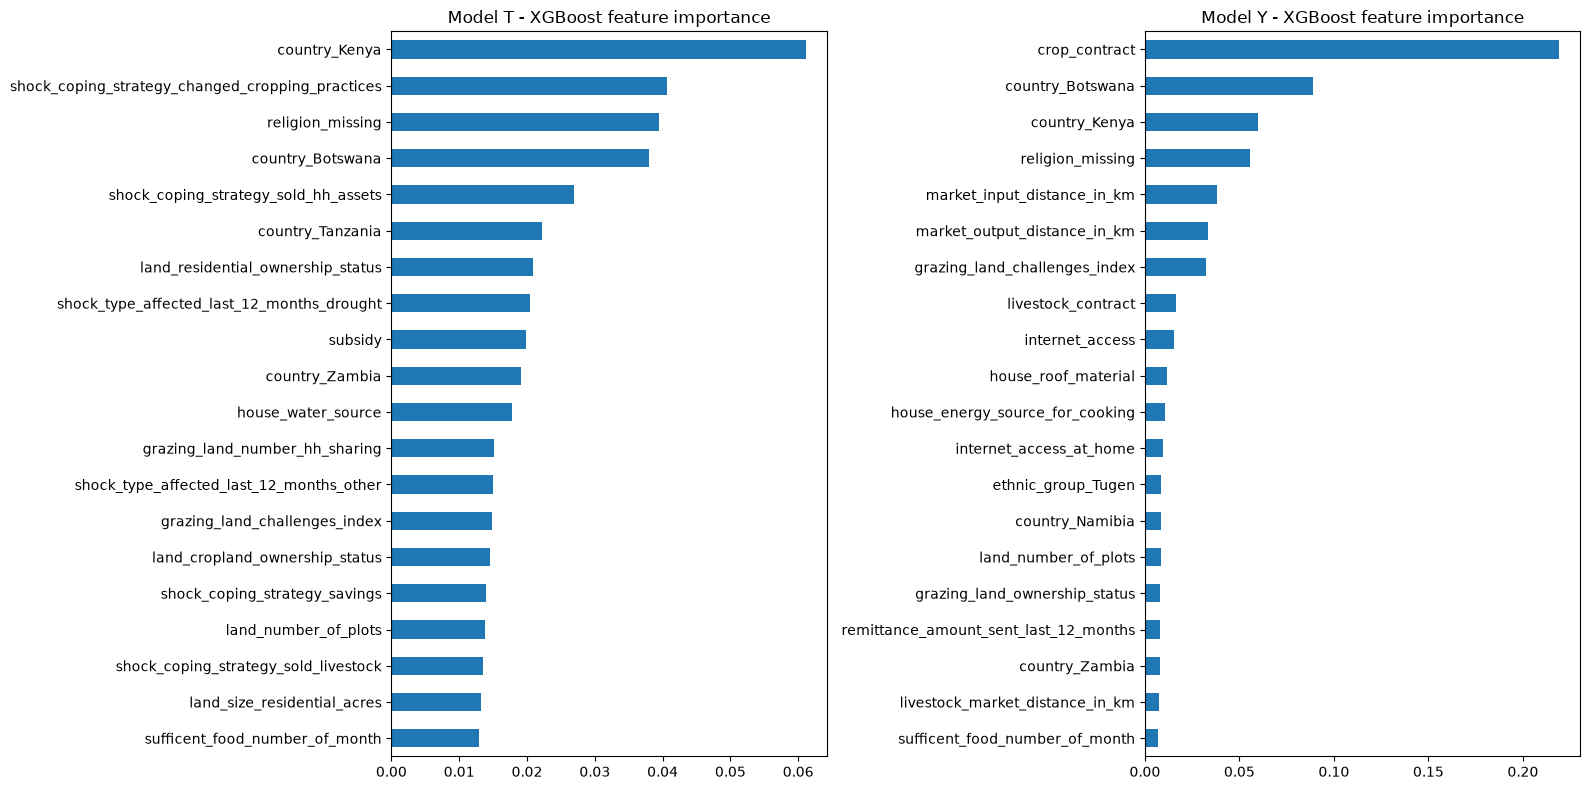

In [179]:
#Looking at feature importance
feature_names = X + W

model_t_fitted = est.models_t[0][1]
model_y_fitted = est.models_y[0][1]

def top_importances(model, feature_names, top_n=20):
    return (pd.Series(model.feature_importances_, index=feature_names)
              .sort_values(ascending=False)
              .head(top_n))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_importances(model_t_fitted, feature_names).sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title("Model T - XGBoost feature importance")

top_importances(model_y_fitted, feature_names).sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title("Model Y - XGBoost feature importance")

plt.tight_layout()
plt.show()

Model T - SHAP summary


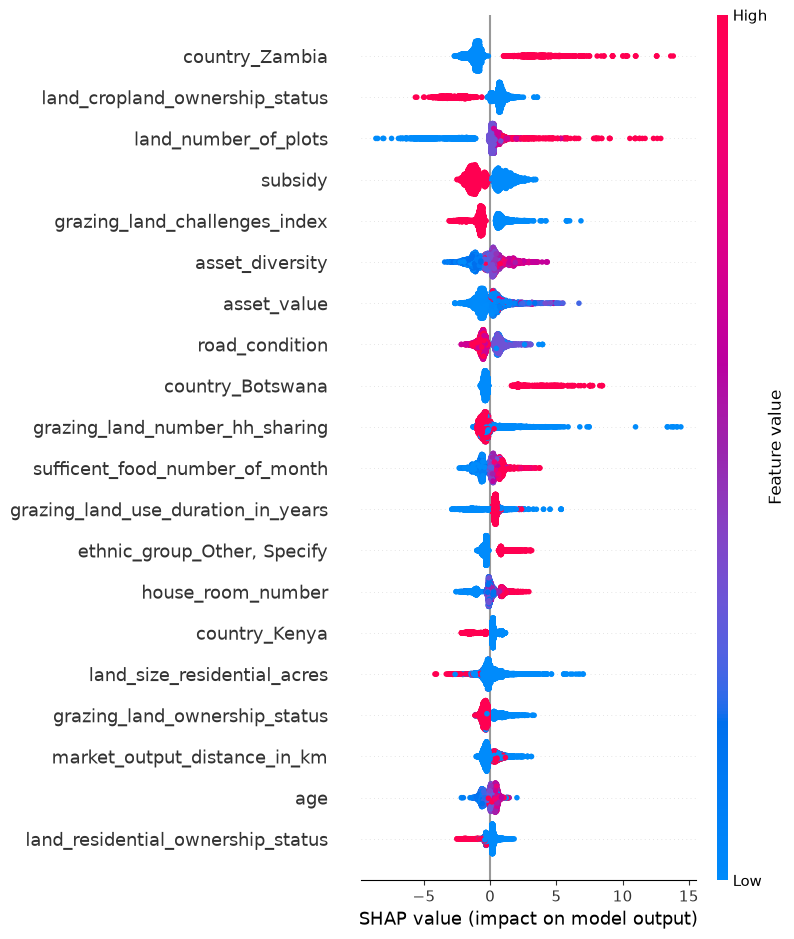

In [180]:
# SHAP values for the same two first-stage models (uses the XW array from above)
XW_df = pd.DataFrame(XW, columns=feature_names)

explainer_t = shap.TreeExplainer(model_t_fitted)
shap_values_t = explainer_t.shap_values(XW_df)

print("Model T - SHAP summary")
shap.summary_plot(shap_values_t, XW_df, show=True)

Model Y - SHAP summary


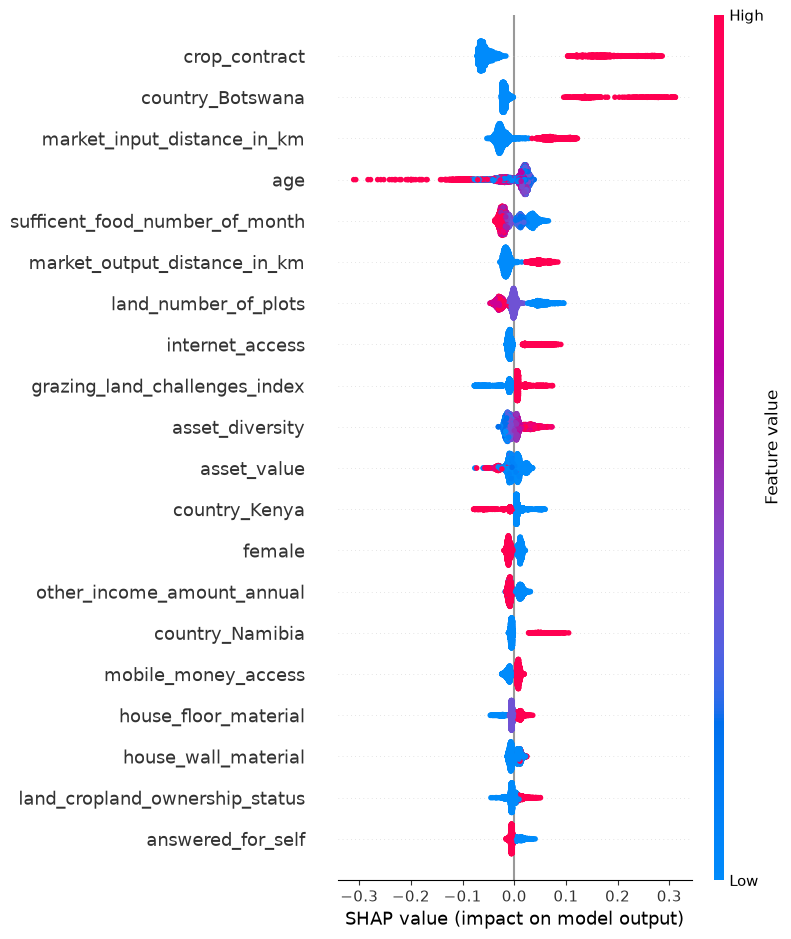

In [181]:
explainer_y = shap.TreeExplainer(model_y_fitted)
shap_values_y = explainer_y.shap_values(XW_df)

print("Model Y - SHAP summary")
shap.summary_plot(shap_values_y, XW_df, show=True)

### 5.2 Second Stage: CausalForest

In [182]:
#Calculate the treatment effects on the TRAINING DATASET
#Due to a continuous treatment, I get marginal treatment effects!
effects = est.effect(df[X])
mean_effect = effects.mean()
print(f"On average, for every 1-unit increase in your treatment score (moving from, say, 50 to 51), the outcome variable changes by {mean_effect} points.")

On average, for every 1-unit increase in your treatment score (moving from, say, 50 to 51), the outcome variable changes by -0.00031112535133553617 points.


In [183]:
#get the upper and lower bound of the CATE estimates
lb, ub = est.effect_interval(df[X], alpha=0.01)

In [184]:
res = est.effect_inference(df[X])
#Looking at each point estimate including p values for each individual 
print(res.summary_frame().head())
# Another way of calculating the mean treatment effect?
print(res.summary_frame()['point_estimate'].mean())

   point_estimate  stderr  zstat  pvalue  ci_lower  ci_upper
X                                                           
0           0.001   0.001  1.543   0.123    -0.000     0.003
1          -0.000   0.001 -0.086   0.932    -0.002     0.001
2           0.002   0.001  1.650   0.099    -0.000     0.003
3          -0.000   0.001 -0.130   0.896    -0.001     0.001
4          -0.001   0.001 -0.686   0.493    -0.003     0.001
-0.00033318758198513335


In [102]:
# mean_point is the mean treatment effect estimate
res.population_summary()

### 5.3 Treatment heterogeneity

In [103]:
# plt.scatter(df['years_of_schooling'], effects, alpha=0.3)
# plt.ylabel('CATE')
# plt.xlabel('years_of_schooling')

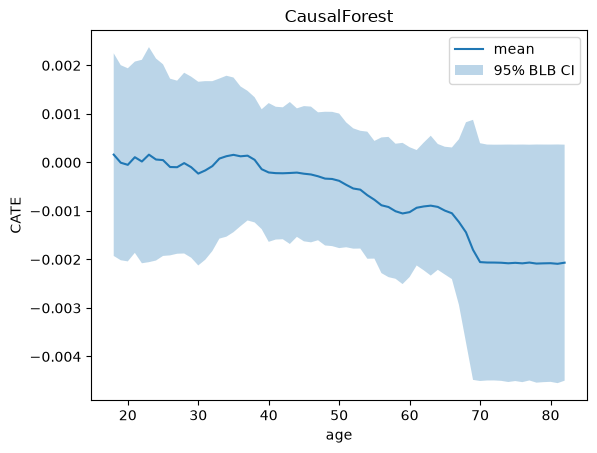

In [115]:
# Plot the estimated treatment heterogeneity with respect to a feature
feat_of_interest = "age"

df['treatment_effect'] = effects
df["lb"] = lb
df["ub"] = ub
avg_effect = (
    df.groupby(feat_of_interest)[["treatment_effect", "lb", "ub"]]
      .mean()
      .reset_index()
)


plt.subplot()
plt.title("CausalForest")
plt.plot(avg_effect[feat_of_interest], avg_effect["treatment_effect"], label='mean')
plt.fill_between(avg_effect[feat_of_interest], avg_effect["lb"], avg_effect["ub"], label="95% BLB CI", alpha=0.3)

plt.ylabel("CATE")
plt.xlabel(f"{feat_of_interest}")
plt.legend()
plt.show()

Text(0.5, 0, 'age')

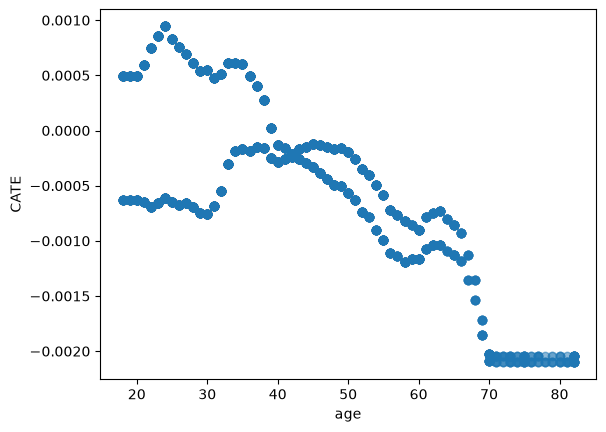

In [114]:
plt.scatter(df['age'], effects, alpha=0.3)
plt.ylabel('CATE')
plt.xlabel('age')

<Axes: xlabel='female'>

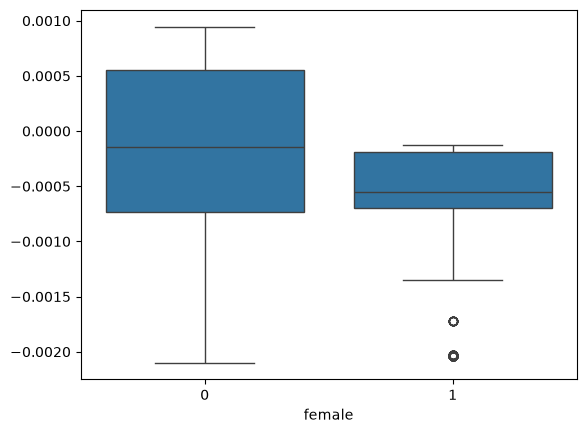

In [106]:

sns.boxplot(x=df['female'], y=effects)

In [107]:
# plt.scatter(df['relation_to_head'], effects, alpha=0.3)
# plt.ylabel('CATE')
# plt.xlabel('relation_to_head')

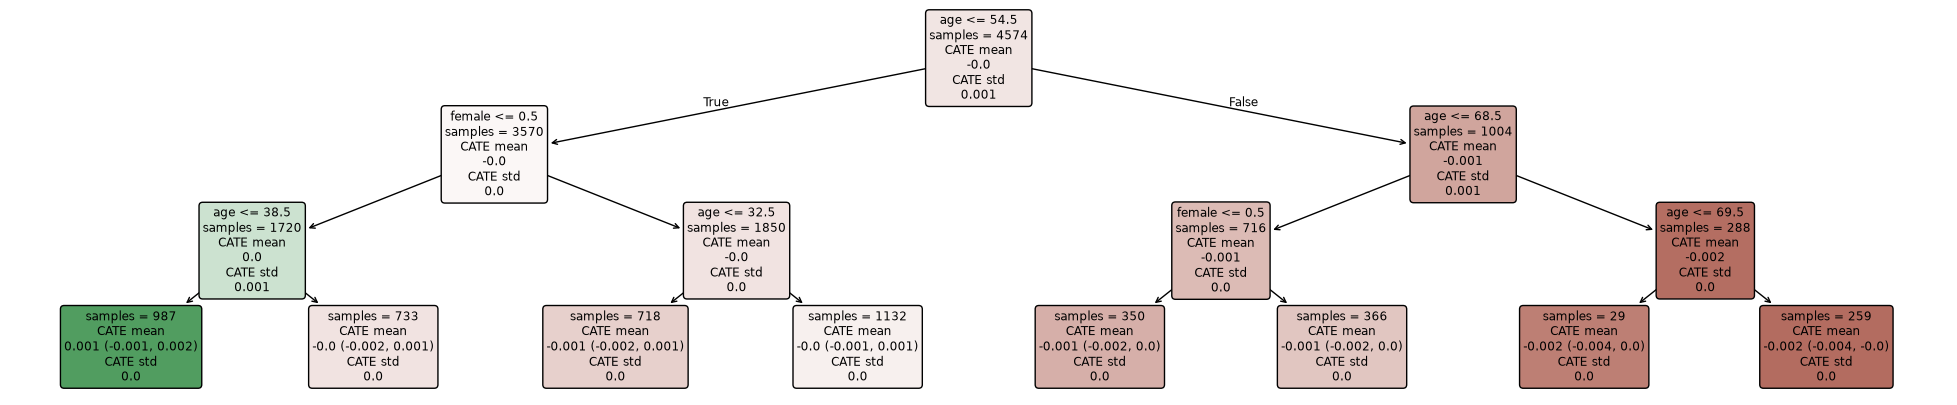

In [108]:
intrp = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=3, min_samples_leaf=10,random_state=42)
intrp.interpret(est, df[X])
plt.figure(figsize=(25, 5))
intrp.plot(feature_names=df[X].columns)

In [186]:
print('Feature Importance for treatment heterogeneity')
pd.DataFrame(est.feature_importances_,
             index=X,
             columns=['feature_importances']
             ).sort_values('feature_importances', ascending=False)


Feature Importance for treatment heterogeneity


,feature_importances
age,0.843747
female,0.156253


In [193]:
# Get shap values
shap_values = est.shap_values(df[X])

Background dataset has 4574 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4574 when initializing the masker.
 99%|===================| 4515/4574 [00:37<00:00]        

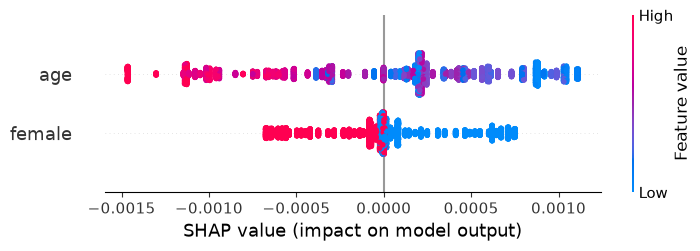

In [199]:
shap.plots.beeswarm(shap_values['off_farm_hours_annual_share']['agriculture_land_acres'])


### 5.3 Additionally proving heterogeneity

In [117]:
#COMPARISON OF MEANS AT THE END OF THE CATE DISTRIBUTION (E.G. BOTTOM VS. TOP DECILE)
from scipy import stats

cate = effects  # array of CATE estimates, one per row in df

# thresholds for bottom 10% and top 10% of the CATE distribution
low, high = np.percentile(cate, [10, 90])

bottom_decile = df[cate <= low]
top_decile = df[cate >= high]

print("Bottom decile (lowest CATE) - mean age:", bottom_decile['age'].mean())
print("Top decile (highest CATE) - mean age:", top_decile['age'].mean())

print("Bottom decile (lowest CATE) - mean female:", bottom_decile['female'].mean())
print("Top decile (highest CATE) - mean female:", top_decile['female'].mean())

print("Test for statistical significance of the difference in means between bottom and top decile:")
for col in ["age", "female"]:
    t, p = stats.ttest_ind(bottom_decile[col], top_decile[col], equal_var=False)
    print(f"{col}: p = {p:.4g}")

Bottom decile (lowest CATE) - mean age: 69.70652173913044
Top decile (highest CATE) - mean age: 27.572354211663068
Bottom decile (lowest CATE) - mean female: 0.33260869565217394
Top decile (highest CATE) - mean female: 0.0
Test for statistical significance of the difference in means between bottom and top decile:
age: p = 0
female: p = 3.186e-42


In [ ]:
# # THIS IS TRYING TO CALCULATE THE BEST LINEAR PREDICTOR FOR THE CATE ESTIMATES; BUT MIGHT BE WRONG!!!!

# import numpy as np
# import statsmodels.api as sm
# from sklearn.model_selection import train_test_split
# from econml.dml import CausalForestDML

# # 1. Train/Validation Split
# X_tr, X_val, T_tr, T_val, Y_tr, Y_val, W_tr, W_val = train_test_split(
#     df[X], df[T], df[Y], df[W], test_size=0.5, random_state=42
# )

# est = CausalForestDML(
#     model_y=first_stage_outcome_model,
#     model_t=first_stage_treatment_model,
#     discrete_outcome=False,   #use a regression, not a classification
#     discrete_treatment=False, #use a regression, not a classification
#     n_estimators=1000,        # High number of trees ensures stable causal predictions
#     min_samples_leaf=50,      # Minimum rows per leaf protects continuous slope estimation
#     cv=3,                     # 3-fold cross-fitting splits your 4500 rows into safe validation chunks
#     random_state=42
# )

# est.fit(Y_tr, T_tr, X=X_tr, W=W_tr,cache_values=True)

# cate_val = est.effect(X_val)         
# c = cate_val - np.mean(cate_val)      # Center predictions

# est_val = CausalForestDML(
#     model_y=first_stage_outcome_model,
#     model_t=first_stage_treatment_model,
#     discrete_outcome=False,   #use a regression, not a classification
#     discrete_treatment=False, #use a regression, not a classification
#     n_estimators=1000,        # High number of trees ensures stable causal predictions
#     min_samples_leaf=50,      # Minimum rows per leaf protects continuous slope estimation
#     cv=3,                     # 3-fold cross-fitting splits your 4500 rows into safe validation chunks
#     random_state=42
# )
# est_val.fit(Y_val, T_val, X=X_val, W=W_val, cache_values=True)

# # Safely extract 1D residuals
# Y_res = est_val.residuals_[0]
# T_res = est_val.residuals_[1]

# X_blp = np.column_stack([T_res, T_res * c])

# blp_model = sm.OLS(Y_res, X_blp).fit(cov_type='HC1')
# print(blp_model.summary(xname=['ATE_slope', 'CATE_heterogeneity_slope']))

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.001
Model:                            OLS   Adj. R-squared (uncentered):             -0.000
Method:                 Least Squares   F-statistic:                             0.8632
Date:                Fri, 04 Sep 2026   Prob (F-statistic):                       0.422
Time:                        14:24:54   Log-Likelihood:                         -394.15
No. Observations:                2287   AIC:                                      792.3
Df Residuals:                    2285   BIC:                                      803.8
Df Model:                           2                                                  
Covariance Type:                  HC1                                                  
                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------